### Delivery Time Regression Task

- `distance_km` 배송 거리 km
- `package_weight_kg` 화물 무게 kg
- `traffic_index` 경로 교통 혼잡도 1~10
- `weather_index` 날씨 악화 정도 1=맑음 10=폭우/폭설
- `depart_hour` 출발 시각 0~23시
- `rush_hour` 출퇴근 시간대 여부 0/1
- `origin_type` 출발지 유형 1=도심, 2=교외, 3=공장
- `dest_type` 목적지 유형 1~3
- `driver_exp_yrs` 드라이버 경력 년
- `stops_count` 경유지 수 개
- `delivery_min` 배송 소요 시간 분 (target)

In [48]:
import pandas as pd

d_df = pd.read_csv('./datasets/07_delivery_time_prediction.csv')
d_df

,distance_km,package_weight_kg,traffic_index,weather_index,depart_hour,rush_hour,origin_type,dest_type,driver_exp_yrs,stops_count,delivery_min
0,30.32,3.86,7.87,1.89,12,0,1,2,4.5,1,114.16
1,19.72,5.99,5.77,2.69,19,1,3,1,0.0,2,77.53
2,19.43,6.19,3.22,2.17,12,0,1,2,2.2,1,54.70
3,25.54,0.20,7.04,1.00,9,1,2,1,0.0,3,109.31
4,27.08,2.57,4.75,2.60,10,0,1,1,9.2,3,90.68
...,...,...,...,...,...,...,...,...,...,...,...
99995,36.76,11.75,4.18,2.03,11,0,1,1,7.0,5,118.83
99996,21.01,11.63,6.13,2.07,13,0,2,1,6.4,1,75.09
99997,42.37,6.66,7.10,2.36,10,0,2,2,8.4,3,153.97
99998,35.38,7.89,5.43,6.27,9,1,3,1,5.4,3,141.20


In [49]:
d_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   distance_km        100000 non-null  float64
 1   package_weight_kg  100000 non-null  float64
 2   traffic_index      100000 non-null  float64
 3   weather_index      100000 non-null  float64
 4   depart_hour        100000 non-null  int64  
 5   rush_hour          100000 non-null  int64  
 6   origin_type        100000 non-null  int64  
 7   dest_type          100000 non-null  int64  
 8   driver_exp_yrs     100000 non-null  float64
 9   stops_count        100000 non-null  int64  
 10  delivery_min       100000 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 8.4 MB


In [50]:
d_df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_km,100000.0,25.221813,14.292826,1.0,14.68,24.91,35.02,88.76
package_weight_kg,100000.0,8.151163,4.742960,0.2,4.66,8.03,11.37,29.66
traffic_index,100000.0,5.007819,1.775156,1.0,3.78,5.00,6.21,10.00
weather_index,100000.0,3.061279,1.383803,1.0,1.99,2.99,4.01,9.59
depart_hour,100000.0,12.998960,3.978165,0.0,10.00,13.00,16.00,23.00
rush_hour,100000.0,0.277240,0.447638,0.0,0.00,0.00,1.00,1.00
origin_type,100000.0,1.651480,0.725975,1.0,1.00,2.00,2.00,3.00
dest_type,100000.0,1.599510,0.733460,1.0,1.00,1.00,2.00,3.00
driver_exp_yrs,100000.0,6.114148,3.758842,0.0,3.30,6.00,8.70,23.90
stops_count,100000.0,2.280980,1.333697,1.0,1.00,2.00,3.00,9.00


In [51]:
d_df.isna().sum()

distance_km          0
package_weight_kg    0
traffic_index        0
weather_index        0
depart_hour          0
rush_hour            0
origin_type          0
dest_type            0
driver_exp_yrs       0
stops_count          0
delivery_min         0
dtype: int64

In [52]:
d_df.duplicated().sum()

np.int64(0)

In [53]:
d_df.sort_values(by='delivery_min').head(10)

,distance_km,package_weight_kg,traffic_index,weather_index,depart_hour,rush_hour,origin_type,dest_type,driver_exp_yrs,stops_count,delivery_min
23283,1.00,0.20,2.19,3.18,15,0,3,1,6.9,1,5.0
98490,1.00,17.79,4.69,3.81,11,0,1,2,13.7,1,5.0
54131,1.00,1.41,4.27,3.21,12,0,2,1,6.3,1,5.0
63600,1.00,4.40,5.60,3.48,16,0,1,1,8.9,1,5.0
42413,1.00,1.84,3.66,1.75,13,0,1,1,10.6,1,5.0
20691,1.00,4.93,2.09,3.70,13,0,2,1,9.1,1,5.0
60143,1.00,2.48,5.85,5.15,16,0,1,1,10.8,1,5.0
38696,1.76,3.51,4.13,3.35,14,0,1,1,7.2,1,5.0
6221,1.00,5.71,2.60,1.00,10,0,1,2,9.9,1,5.0
13374,1.00,2.88,3.48,3.95,16,0,1,2,13.2,1,5.0


In [54]:
d_df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_km,100000.0,25.221813,14.292826,1.0,14.68,24.91,35.02,88.76
package_weight_kg,100000.0,8.151163,4.742960,0.2,4.66,8.03,11.37,29.66
traffic_index,100000.0,5.007819,1.775156,1.0,3.78,5.00,6.21,10.00
weather_index,100000.0,3.061279,1.383803,1.0,1.99,2.99,4.01,9.59
depart_hour,100000.0,12.998960,3.978165,0.0,10.00,13.00,16.00,23.00
rush_hour,100000.0,0.277240,0.447638,0.0,0.00,0.00,1.00,1.00
origin_type,100000.0,1.651480,0.725975,1.0,1.00,2.00,2.00,3.00
dest_type,100000.0,1.599510,0.733460,1.0,1.00,1.00,2.00,3.00
driver_exp_yrs,100000.0,6.114148,3.758842,0.0,3.30,6.00,8.70,23.90
stops_count,100000.0,2.280980,1.333697,1.0,1.00,2.00,3.00,9.00


In [55]:
d_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   distance_km        100000 non-null  float64
 1   package_weight_kg  100000 non-null  float64
 2   traffic_index      100000 non-null  float64
 3   weather_index      100000 non-null  float64
 4   depart_hour        100000 non-null  int64  
 5   rush_hour          100000 non-null  int64  
 6   origin_type        100000 non-null  int64  
 7   dest_type          100000 non-null  int64  
 8   driver_exp_yrs     100000 non-null  float64
 9   stops_count        100000 non-null  int64  
 10  delivery_min       100000 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 8.4 MB


In [56]:
d_df.drop(['package_weight_kg', 'depart_hour', 'origin_type', 'dest_type'], axis=1, inplace=True)


In [57]:
d_df

,distance_km,traffic_index,weather_index,rush_hour,driver_exp_yrs,stops_count,delivery_min
0,30.32,7.87,1.89,0,4.5,1,114.16
1,19.72,5.77,2.69,1,0.0,2,77.53
2,19.43,3.22,2.17,0,2.2,1,54.70
3,25.54,7.04,1.00,1,0.0,3,109.31
4,27.08,4.75,2.60,0,9.2,3,90.68
...,...,...,...,...,...,...,...
99995,36.76,4.18,2.03,0,7.0,5,118.83
99996,21.01,6.13,2.07,0,6.4,1,75.09
99997,42.37,7.10,2.36,0,8.4,3,153.97
99998,35.38,5.43,6.27,1,5.4,3,141.20


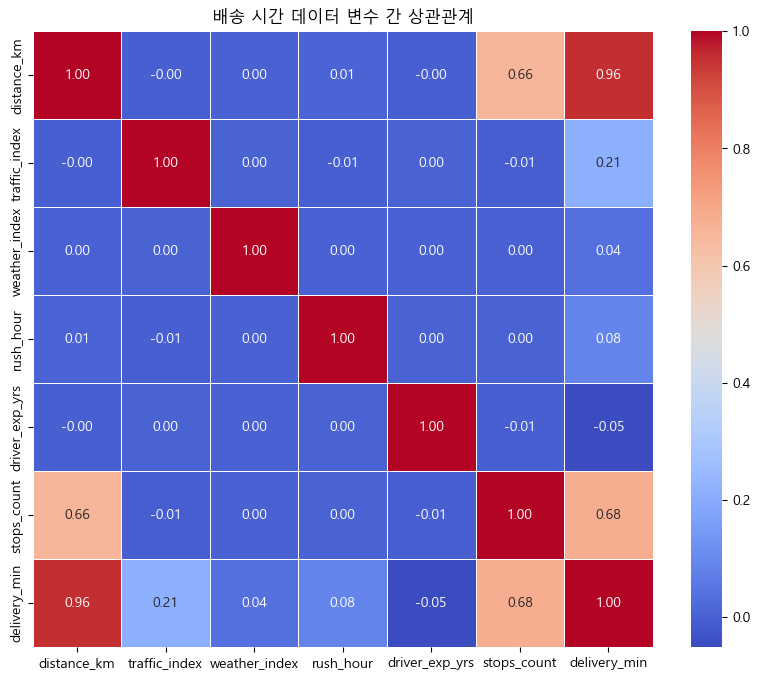

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상관계수 계산
corr = d_df.corr()

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('배송 시간 데이터 변수 간 상관관계')
plt.show()

In [59]:
d_df.corr()

,distance_km,traffic_index,weather_index,rush_hour,driver_exp_yrs,stops_count,delivery_min
distance_km,1.000000,-0.004505,0.000518,0.007252,-0.002914,0.655527,0.955300
traffic_index,-0.004505,1.000000,0.002792,-0.005030,0.004220,-0.007475,0.211363
weather_index,0.000518,0.002792,1.000000,0.001805,0.001380,0.000447,0.036410
rush_hour,0.007252,-0.005030,0.001805,1.000000,0.003547,0.004608,0.084568
driver_exp_yrs,-0.002914,0.004220,0.001380,0.003547,1.000000,-0.005241,-0.051202
stops_count,0.655527,-0.007475,0.000447,0.004608,-0.005241,1.000000,0.683533
delivery_min,0.955300,0.211363,0.036410,0.084568,-0.051202,0.683533,1.000000


array([[<Axes: title={'center': 'distance_km'}>,
        <Axes: title={'center': 'traffic_index'}>,
        <Axes: title={'center': 'weather_index'}>],
       [<Axes: title={'center': 'rush_hour'}>,
        <Axes: title={'center': 'driver_exp_yrs'}>,
        <Axes: title={'center': 'stops_count'}>],
       [<Axes: title={'center': 'delivery_min'}>, <Axes: >, <Axes: >]],
      dtype=object)

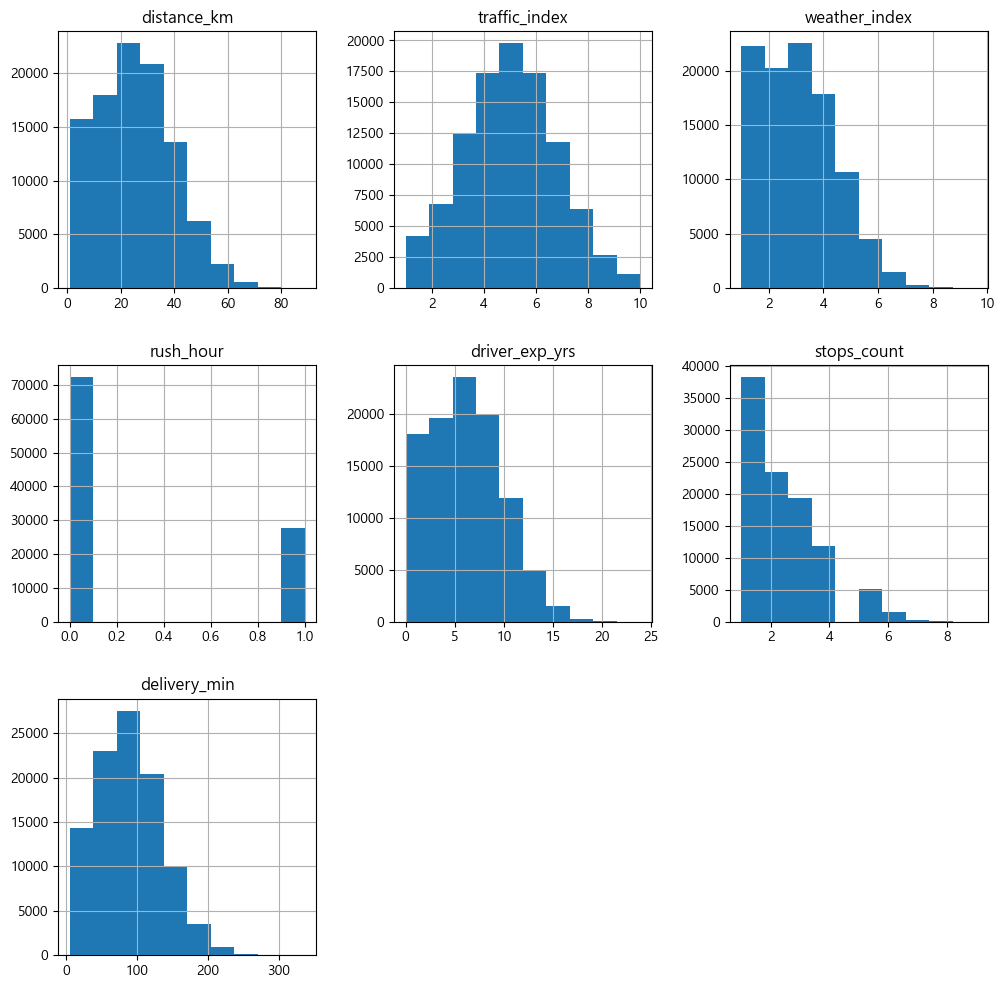

In [60]:
d_df.hist(figsize=(12, 12))

In [90]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.pairplot(d_df)
# plt.show()

In [62]:
import numpy as np
import pandas as pd

for column in d_df.columns:
        Q1 = np.percentile(d_df[column], 25)
        Q3 = np.percentile(d_df[column], 75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        condition1 = d_df[column] >= lower_bound
        condition2 = d_df[column] <= upper_bound
        condition = condition1 & condition2
        
        d_df = d_df[condition]

d_df

,distance_km,traffic_index,weather_index,rush_hour,driver_exp_yrs,stops_count,delivery_min
0,30.32,7.87,1.89,0,4.5,1,114.16
1,19.72,5.77,2.69,1,0.0,2,77.53
2,19.43,3.22,2.17,0,2.2,1,54.70
3,25.54,7.04,1.00,1,0.0,3,109.31
4,27.08,4.75,2.60,0,9.2,3,90.68
...,...,...,...,...,...,...,...
99995,36.76,4.18,2.03,0,7.0,5,118.83
99996,21.01,6.13,2.07,0,6.4,1,75.09
99997,42.37,7.10,2.36,0,8.4,3,153.97
99998,35.38,5.43,6.27,1,5.4,3,141.20


In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF < 5: 매우 양호 (독립성이 높음)
# VIF < 10: 수용 가능 (약간의 상관관계가 있으나 문제없음)
# VIF > 10: 위험 (다중공선성 존재, 변수 제거 또는 처리가 필요함)
# 만약 어떤 변수의 VIF가 20 ~ 30이라면, 그 변수는 빼거나 다른 것과 합쳐서 해결한다.
def feature_engineering_VIF(features):
    vif = pd.DataFrame()
    vif['vif_score'] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
    vif['feature'] = features.columns
    return vif

In [64]:
features = d_df.drop('delivery_min', axis=1)
feature_engineering_VIF(features)

,vif_score,feature
0,6.809331,distance_km
1,5.555768,traffic_index
2,4.593522,weather_index
3,1.356893,rush_hour
4,3.233252,driver_exp_yrs
5,6.604279,stops_count


In [65]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def get_evaluation(y_test, prediction):
    MAE =  mean_absolute_error(y_test, prediction)
    MSE = mean_squared_error(y_test, prediction)
    RMSE = np.sqrt(MSE)
    MSLE = mean_squared_log_error(y_test, prediction)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, prediction))
    R2 = r2_score(y_test, prediction)

    print('MAE: {:.4f}, MSE: {:.4f}, RMSE: {:.4f}, MSLE: {:.4f}, RMSLE: {:.4f}, R2: {:.4f}'.format(MAE, MSE, RMSE, MSLE, RMSLE, R2))

In [66]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features, targets = d_df.drop('delivery_min', axis=1), d_df.delivery_min

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

l_r = LinearRegression()
l_r.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
get_evaluation(y_test, np.maximum(l_r.predict(X_test), 0))

MAE: 5.3434, MSE: 48.6969, RMSE: 6.9783, MSLE: 0.0712, RMSLE: 0.2669, R2: 0.9744


In [68]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

features, targets = d_df.iloc[:, :-1], d_df.delivery_min

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

y_train = np.log1p(y_train)

dt_reg = DecisionTreeRegressor(random_state=124, max_depth=4)
rf_reg = RandomForestRegressor(random_state=124, n_estimators=500, max_depth=6)
gb_reg = GradientBoostingRegressor(random_state=124, n_estimators=1000, max_depth=8)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=4, learning_rate=0.01)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=4, learning_rate=0.01)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:  
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(model.__class__.__name__)
    get_evaluation(y_test, np.expm1(prediction))

DecisionTreeRegressor
MAE: 9.9862, MSE: 175.3082, RMSE: 13.2404, MSLE: 0.0279, RMSLE: 0.1669, R2: 0.9077
RandomForestRegressor
MAE: 6.4712, MSE: 70.3109, RMSE: 8.3852, MSLE: 0.0159, RMSLE: 0.1260, R2: 0.9630
GradientBoostingRegressor
MAE: 3.8159, MSE: 22.8022, RMSE: 4.7752, MSLE: 0.0117, RMSLE: 0.1080, R2: 0.9880
XGBRegressor
MAE: 3.6725, MSE: 21.1610, RMSE: 4.6001, MSLE: 0.0101, RMSLE: 0.1003, R2: 0.9889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004968 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 942
[LightGBM] [Info] Number of data points in the train set: 78317, number of used features: 6
[LightGBM] [Info] Start training from score 4.320765
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

In [88]:
dt_reg.feature_importances_.round(3)

array([0.036, 0.   , 0.017, 0.006, 0.941])

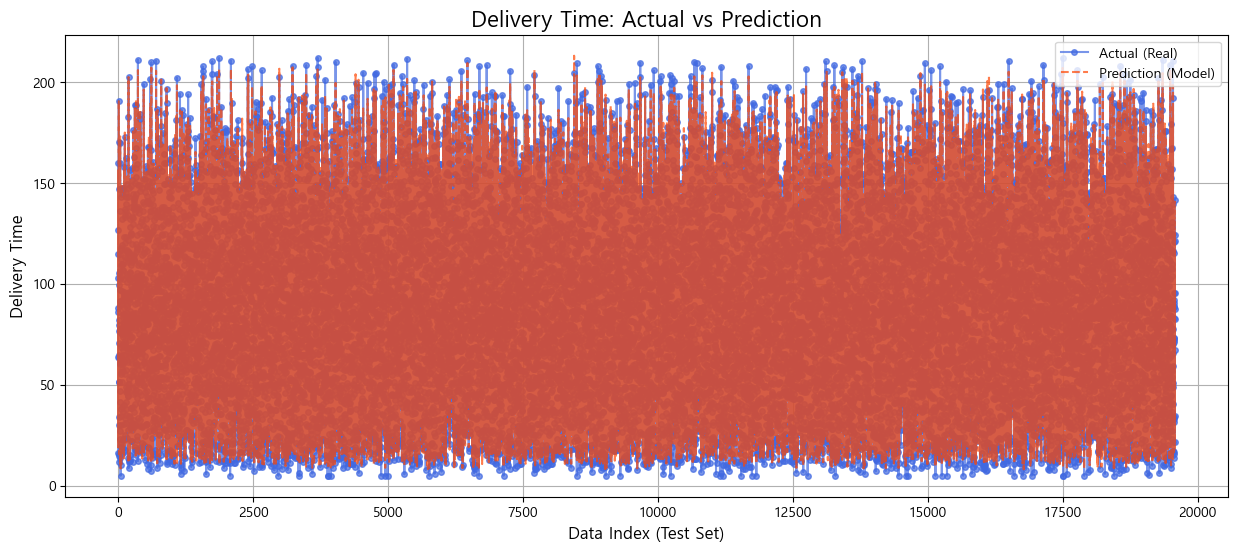

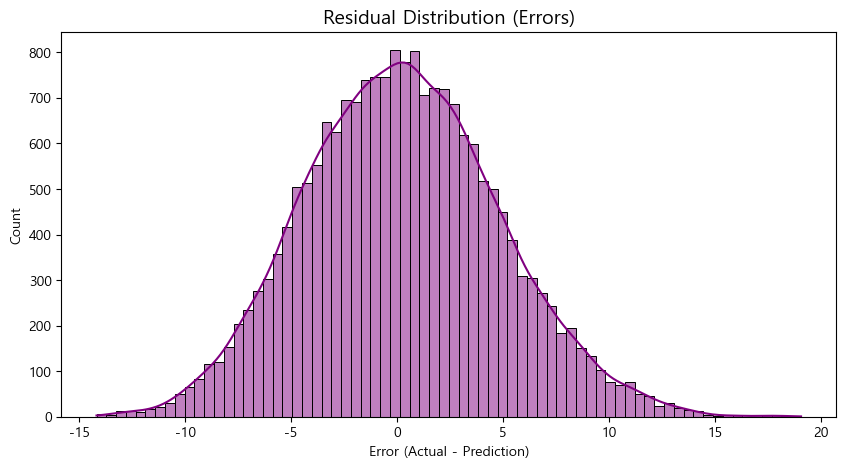

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Prediction': np.expm1(prediction) # 로그 복원
}).reset_index(drop=True)

# 오차 차이
plt.figure(figsize=(15, 6))
plt.plot(comparison_df['Actual'], label='Actual (Real)', color='royalblue', alpha=0.7, marker='o', markersize=4)
plt.plot(comparison_df['Prediction'], label='Prediction (Model)', color='orangered', alpha=0.7, linestyle='--')

plt.title('Delivery Time: Actual vs Prediction', fontsize=16)
plt.xlabel('Data Index (Test Set)', fontsize=12)
plt.ylabel('Delivery Time', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# 오차 분포
plt.figure(figsize=(10, 5))
sns.histplot(comparison_df['Actual'] - comparison_df['Prediction'], kde=True, color='purple')
plt.title('Residual Distribution (Errors)', fontsize=14)
plt.xlabel('Error (Actual - Prediction)')
plt.show()

#### Feature Engineering 하기.
1. dist_per_stop: 경유지당 평균 거리
2. dist_x_traffic: 거리와 교통상황index 곱하기
3. traffic_x_weather: 교통상황과 날씨상황 곱하기

In [70]:
pre1_d_df = d_df.copy()

In [71]:
pre1_d_df['dist_per_stop'] = d_df['distance_km'] / d_df['stops_count']
pre1_d_df

,distance_km,traffic_index,weather_index,rush_hour,driver_exp_yrs,stops_count,delivery_min,dist_per_stop
0,30.32,7.87,1.89,0,4.5,1,114.16,30.320000
1,19.72,5.77,2.69,1,0.0,2,77.53,9.860000
2,19.43,3.22,2.17,0,2.2,1,54.70,19.430000
3,25.54,7.04,1.00,1,0.0,3,109.31,8.513333
4,27.08,4.75,2.60,0,9.2,3,90.68,9.026667
...,...,...,...,...,...,...,...,...
99995,36.76,4.18,2.03,0,7.0,5,118.83,7.352000
99996,21.01,6.13,2.07,0,6.4,1,75.09,21.010000
99997,42.37,7.10,2.36,0,8.4,3,153.97,14.123333
99998,35.38,5.43,6.27,1,5.4,3,141.20,11.793333


In [72]:
pre1_d_df.drop(['distance_km', 'stops_count'], axis=1, inplace=True)

In [73]:
feature_engineering_VIF(pre1_d_df.drop('delivery_min', axis=1))

,vif_score,feature
0,5.398104,traffic_index
1,4.488942,weather_index
2,1.354551,rush_hour
3,3.200502,driver_exp_yrs
4,3.121441,dist_per_stop


In [74]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

features, targets = pre1_d_df.drop('delivery_min', axis=1), pre1_d_df.delivery_min

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=124)

scale = StandardScaler()

X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

y_train = np.log1p(y_train)

dt_reg = DecisionTreeRegressor(random_state=124, max_depth=6)
rf_reg = RandomForestRegressor(random_state=124, n_estimators=500, max_depth=6)
gb_reg = GradientBoostingRegressor(random_state=124, n_estimators=500, max_depth=6)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:  
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(model.__class__.__name__)
    get_evaluation(y_test, np.expm1(prediction))

DecisionTreeRegressor
MAE: 27.3767, MSE: 1245.1416, RMSE: 35.2866, MSLE: 0.1672, RMSLE: 0.4089, R2: 0.3443
RandomForestRegressor
MAE: 27.2130, MSE: 1232.3046, RMSE: 35.1042, MSLE: 0.1646, RMSLE: 0.4057, R2: 0.3510
GradientBoostingRegressor
MAE: 26.5036, MSE: 1190.8323, RMSE: 34.5084, MSLE: 0.1597, RMSLE: 0.3996, R2: 0.3729
XGBRegressor
MAE: 26.7791, MSE: 1212.9885, RMSE: 34.8280, MSLE: 0.1623, RMSLE: 0.4029, R2: 0.3612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 937
[LightGBM] [Info] Number of data points in the train set: 78317, number of used features: 5
[LightGBM] [Info] Start training from score 4.320765
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

C:\Users\sokko\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LGBMRegressor
MAE: 26.7733, MSE: 1211.6267, RMSE: 34.8084, MSLE: 0.1620, RMSLE: 0.4025, R2: 0.3619


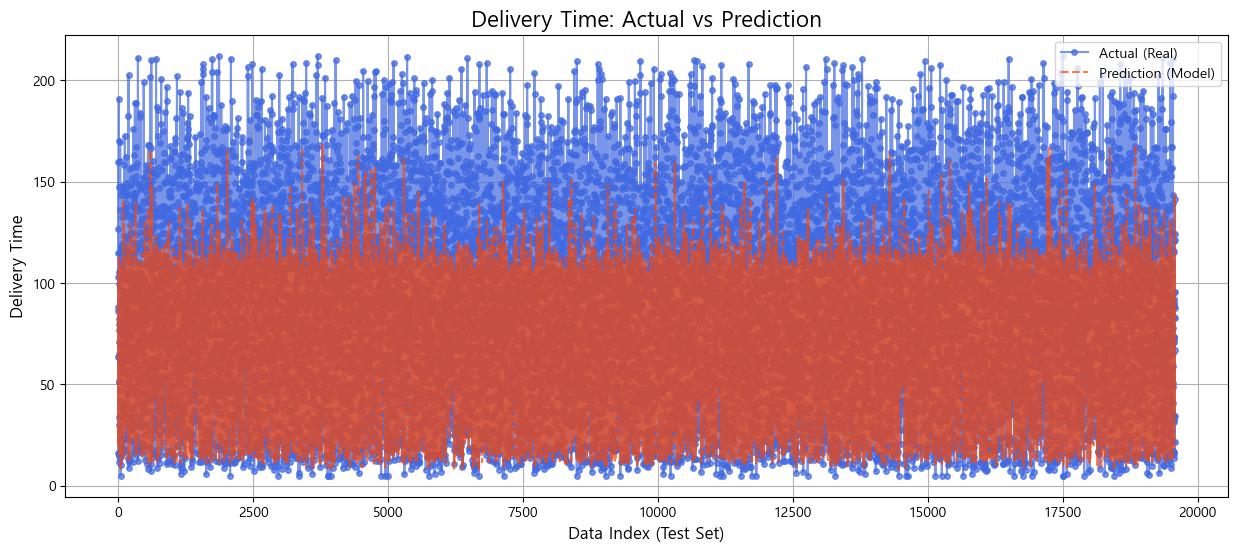

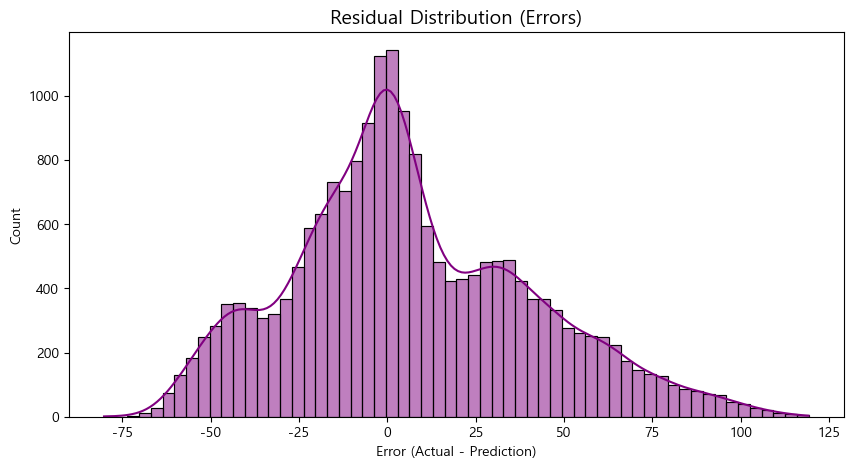

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Prediction': np.expm1(prediction) # 로그 복원
}).reset_index(drop=True)

# 오차 차이
plt.figure(figsize=(15, 6))
plt.plot(comparison_df['Actual'], label='Actual (Real)', color='royalblue', alpha=0.7, marker='o', markersize=4)
plt.plot(comparison_df['Prediction'], label='Prediction (Model)', color='orangered', alpha=0.7, linestyle='--')

plt.title('Delivery Time: Actual vs Prediction', fontsize=16)
plt.xlabel('Data Index (Test Set)', fontsize=12)
plt.ylabel('Delivery Time', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# 오차 분포
plt.figure(figsize=(10, 5))
sns.histplot(comparison_df['Actual'] - comparison_df['Prediction'], kde=True, color='purple')
plt.title('Residual Distribution (Errors)', fontsize=14)
plt.xlabel('Error (Actual - Prediction)')
plt.show()

#### Feature Engineering 두번쨰

In [76]:
pre2_d_df = d_df.copy()
pre2_d_df['dist_x_traffic'] = d_df['distance_km'] * d_df['traffic_index']
pre2_d_df

,distance_km,traffic_index,weather_index,rush_hour,driver_exp_yrs,stops_count,delivery_min,dist_x_traffic
0,30.32,7.87,1.89,0,4.5,1,114.16,238.6184
1,19.72,5.77,2.69,1,0.0,2,77.53,113.7844
2,19.43,3.22,2.17,0,2.2,1,54.70,62.5646
3,25.54,7.04,1.00,1,0.0,3,109.31,179.8016
4,27.08,4.75,2.60,0,9.2,3,90.68,128.6300
...,...,...,...,...,...,...,...,...
99995,36.76,4.18,2.03,0,7.0,5,118.83,153.6568
99996,21.01,6.13,2.07,0,6.4,1,75.09,128.7913
99997,42.37,7.10,2.36,0,8.4,3,153.97,300.8270
99998,35.38,5.43,6.27,1,5.4,3,141.20,192.1134


In [77]:
feature_engineering_VIF(pre2_d_df.drop('delivery_min', axis=1))

,vif_score,feature
0,19.348438,distance_km
1,10.627991,traffic_index
2,5.354758,weather_index
3,1.370944,rush_hour
4,3.486988,driver_exp_yrs
5,6.738199,stops_count
6,17.363833,dist_x_traffic


In [78]:
pre3_d_df = d_df.copy()
pre3_d_df['traffic_x_weather'] = d_df['traffic_index'] + d_df['weather_index']
pre3_d_df.drop(['traffic_index', 'weather_index'], axis=1, inplace=True)
pre3_d_df

,distance_km,rush_hour,driver_exp_yrs,stops_count,delivery_min,traffic_x_weather
0,30.32,0,4.5,1,114.16,9.76
1,19.72,1,0.0,2,77.53,8.46
2,19.43,0,2.2,1,54.70,5.39
3,25.54,1,0.0,3,109.31,8.04
4,27.08,0,9.2,3,90.68,7.35
...,...,...,...,...,...,...
99995,36.76,0,7.0,5,118.83,6.21
99996,21.01,0,6.4,1,75.09,8.20
99997,42.37,0,8.4,3,153.97,9.46
99998,35.38,1,5.4,3,141.20,11.70


In [79]:
feature_engineering_VIF(pre3_d_df.drop('delivery_min', axis=1))

,vif_score,feature
0,6.809142,distance_km
1,1.356868,rush_hour
2,3.233203,driver_exp_yrs
3,6.604180,stops_count
4,5.255335,traffic_x_weather


In [80]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

features, targets = pre1_d_df.drop('delivery_min', axis=1), pre3_d_df.delivery_min

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=124)

scale = StandardScaler()

X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

y_train = np.log1p(y_train)

dt_reg = DecisionTreeRegressor(random_state=124, max_depth=6)
rf_reg = RandomForestRegressor(random_state=124, n_estimators=500, max_depth=6)
gb_reg = GradientBoostingRegressor(random_state=124, n_estimators=500, max_depth=6)
xgb_reg = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)
lgb_reg = LGBMRegressor(n_estimators=1000, max_depth=6, learning_rate=0.01)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:  
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(model.__class__.__name__)
    get_evaluation(y_test, np.expm1(prediction))

DecisionTreeRegressor
MAE: 27.3767, MSE: 1245.1416, RMSE: 35.2866, MSLE: 0.1672, RMSLE: 0.4089, R2: 0.3443
RandomForestRegressor
MAE: 27.2130, MSE: 1232.3046, RMSE: 35.1042, MSLE: 0.1646, RMSLE: 0.4057, R2: 0.3510
GradientBoostingRegressor
MAE: 26.5036, MSE: 1190.8323, RMSE: 34.5084, MSLE: 0.1597, RMSLE: 0.3996, R2: 0.3729
XGBRegressor
MAE: 26.7791, MSE: 1212.9885, RMSE: 34.8280, MSLE: 0.1623, RMSLE: 0.4029, R2: 0.3612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000643 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 937
[LightGBM] [Info] Number of data points in the train set: 78317, number of used features: 5
[LightGBM] [Info] Start training from score 4.320765
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

C:\Users\sokko\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LGBMRegressor
MAE: 26.7733, MSE: 1211.6267, RMSE: 34.8084, MSLE: 0.1620, RMSLE: 0.4025, R2: 0.3619


In [81]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import randint

features, targets = d_df.iloc[:, :-1], d_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=124)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

parameters = {
    'max_depth': randint(2, 10), 
    'min_samples_split': randint(2, 20) 
}

dtr = DecisionTreeRegressor(random_state=124)


random_grid_decision_tree = RandomizedSearchCV(
    dtr, 
    param_distributions=parameters, 
    n_iter=4, 
    cv=3, 
    refit=True, 
    return_train_score=True,
    random_state=124 
)

# 학습
random_grid_decision_tree.fit(X_train_scaled, y_train)

,estimator,DecisionTreeR...dom_state=124)
,param_distributions,"{'max_depth': <scipy.stats....001E35DD3BD60>, 'min_samples_split': <scipy.stats....001E339497A00>}"
,n_iter,4
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [82]:
import pandas as pd

random_scores_df = pd.DataFrame(random_grid_decision_tree.cv_results_)
random_scores_df[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
1,"{'max_depth': 9, 'min_samples_split': 4}",0.977296,1
0,"{'max_depth': 8, 'min_samples_split': 19}",0.973723,2
3,"{'max_depth': 6, 'min_samples_split': 16}",0.962342,3
2,"{'max_depth': 3, 'min_samples_split': 2}",0.892494,4


In [83]:
parameters = {'max_depth':list(range(3, 10)), 'min_samples_split':list(range(2, 20))}

grid_dtr = GridSearchCV(dtr, param_grid=parameters, cv=3, refit=True, return_train_score=True)
grid_dtr.fit(X_train_scaled, y_train)

,estimator,DecisionTreeR...dom_state=124)
,param_grid,"{'max_depth': [3, 4, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


In [84]:
import pandas as pd

grid_scores_df = pd.DataFrame(grid_dtr.cv_results_)
grid_scores_df[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
122,"{'max_depth': 9, 'min_samples_split': 16}",0.977301,1
118,"{'max_depth': 9, 'min_samples_split': 12}",0.977301,2
123,"{'max_depth': 9, 'min_samples_split': 17}",0.977301,3
117,"{'max_depth': 9, 'min_samples_split': 11}",0.977300,4
121,"{'max_depth': 9, 'min_samples_split': 15}",0.977300,5
...,...,...,...
15,"{'max_depth': 3, 'min_samples_split': 17}",0.892494,109
16,"{'max_depth': 3, 'min_samples_split': 18}",0.892494,109
17,"{'max_depth': 3, 'min_samples_split': 19}",0.892494,109
9,"{'max_depth': 3, 'min_samples_split': 11}",0.892494,109


In [85]:
dtr = grid_dtr.best_estimator_
prediction = dtr.predict(X_test_scaled)
get_evaluation(y_test, prediction)

MAE: 5.1417, MSE: 42.3451, RMSE: 6.5073, MSLE: 0.0134, RMSLE: 0.1157, R2: 0.9777


In [89]:
dtr.feature_importances_.round(2)

array([0.93, 0.06, 0.  , 0.01, 0.  , 0.  ])

#### 정리

- LinearRegression만으로 R2가 0.9 이상이었다. 변수와 target이 거의 선형 관계였다.
  
- Feature Engineering은 신중하게 해야한다 distance_km과 stops_count를 하나로 합쳤더니 0.37로 하락했다.

- VIF 체크의 중요성: distance_×_traffic를 만들었더니 원본 변수와의 VIF가 19로 올랐다. 변수 합성 후에는 반드시 다중공선성 재확인을 해야한다.
